In [1]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.inference.model_inversion import MIFace

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

In [15]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 178ms/step - accuracy: 0.2566 - loss: 2.2319 - val_accuracy: 0.4774 - val_loss: 1.4295
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 176ms/step - accuracy: 0.5241 - loss: 1.3186 - val_accuracy: 0.5735 - val_loss: 1.1773
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 169ms/step - accuracy: 0.5930 - loss: 1.1442 - val_accuracy: 0.6262 - val_loss: 1.0792
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 175ms/step - accuracy: 0.6458 - loss: 1.0210 - val_accuracy: 0.6482 - val_loss: 0.9787
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - accuracy: 0.6714 - loss: 0.9292 - val_accuracy: 0.6708 - val_loss: 0.9359
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - accuracy: 0.6982 - loss: 0.8614 - val_accuracy: 0.6720 - val_loss: 0.9509
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 66s 170ms/step - accuracy: 0.7160 - loss: 0.8139 - val_accuracy: 0.6845 - val_loss: 0.8851
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 173ms/step - accuracy: 0.7384 - loss: 0

In [16]:
loss_object = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=10,
    input_shape=(32,32,3),
    loss_object=loss_object,
    clip_values=(0.0,1.0)
)

In [17]:
attack = MIFace(
    classifier,
    max_iter=3000,
    threshold=0.0001,
    verbose=True
)

In [19]:
target_class = 3

y_target = np.zeros((1,10))
y_target[0, target_class] = 1

reconstructed = attack.infer(x=None, y=y_target)

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

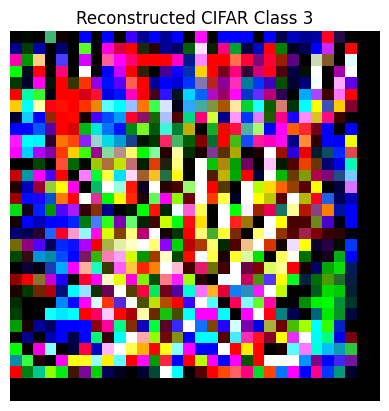

In [20]:
plt.imshow(reconstructed[0])
plt.title(f"Reconstructed CIFAR Class {target_class}")
plt.axis("off")
plt.show()

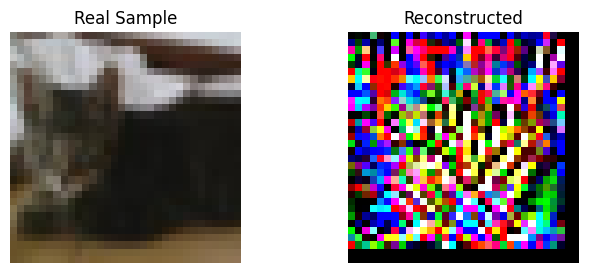

In [21]:
real_sample = x_train[np.where(y_train.flatten()==target_class)[0][0]]

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(real_sample)
plt.title("Real Sample")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed")
plt.axis("off")

plt.show()

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

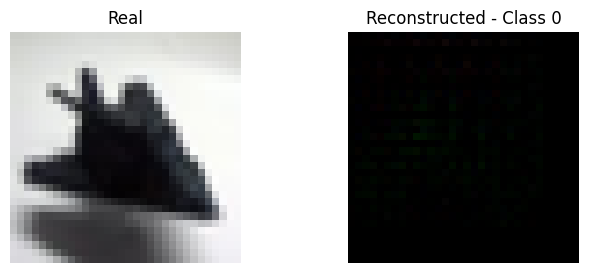

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

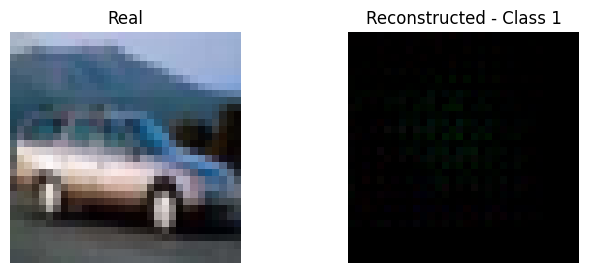

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

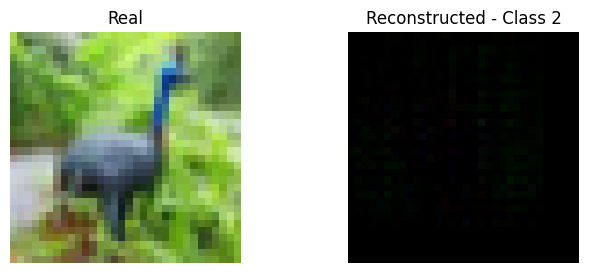

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

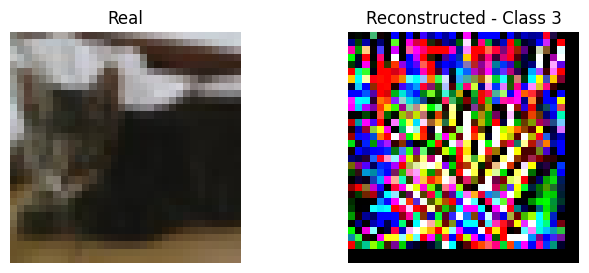

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

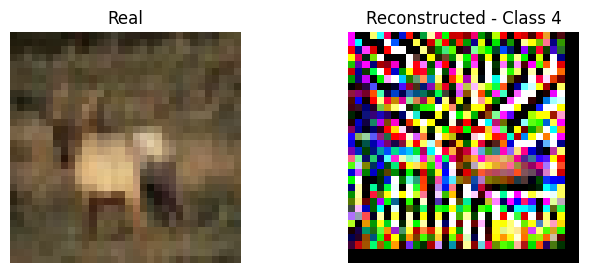

In [22]:
for target_class in [0,1,2,3,4]:

    y_target = np.zeros((1,10))
    y_target[0,target_class] = 1

    reconstructed = attack.infer(x=None, y=y_target)
    real_sample = x_train[np.where(y_train.flatten()==target_class)[0][0]]

    plt.figure(figsize=(8,3))

    plt.subplot(1,2,1)
    plt.imshow(real_sample)
    plt.title("Real")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed[0])
    plt.title(f"Reconstructed - Class {target_class}")
    plt.axis("off")

    plt.show()

# Results and Observations
1. Reconstruction Quality

The MI-Face attack generates representative object prototypes for CIFAR-10 classes. Compared to the AT&T face dataset, reconstructions are more abstract and less sharp. This is expected due to the increased variability and color complexity of CIFAR-10 objects.

2. Increased Difficulty Compared to Faces

Unlike AT&T faces where each class corresponds to one person with limited variation, CIFAR-10 classes contain thousands of diverse samples (e.g., different cats, different angles, lighting). Therefore, MI-Face reconstructs an “average” class template rather than a specific object instance.

3. Privacy Implications

Although CIFAR-10 does not contain sensitive biometric data, this experiment shows that trained models can leak class-specific patterns. In real-world datasets containing proprietary or confidential images, this vulnerability may expose sensitive visual information.

4. Comparison with AT&T Results

Reconstructions from the AT&T dataset appear more identifiable because each class contains fewer individuals with less variation. CIFAR-10 inversions are more blurred due to higher intra-class diversity.

5. Security Insight

This experiment reinforces that even complex convolutional neural networks trained on natural images can leak information about their training data via model inversion attacks.

In [24]:
print("Min:", reconstructed.min())
print("Max:", reconstructed.max())
print("Mean:", reconstructed.mean())

Min: 0.0
Max: 1.0
Mean: 0.3838936
